## <br>
# Plots <br>
# Colorado extRemes analysis on AFI with CI and CV<br>
Model 0 : Stationary<br>
Model 1 : Location parameter varies in time via GLOST<br>
'Loc: time':  location.fun= ~ glost <br>
Model 2 : Location and Scale parameters vary in time via GLOST<br>
'Loc & scale: time':  location.fun= ~ glost, scale.fun = ~glost <br>

In [2]:
import os

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
from copy import copy


In [3]:
from matplotlib import cm

In [4]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [5]:
import warnings
warnings.filterwarnings('ignore')


# READ FILES

In [ ]:
yearb=1941
yeare=2025
B=1000

ds0 = xr.open_dataset(f'Colorado_extRemes_CV_CI_1941_2025.nc')
rl0 = ds0['rl']
loc0 = ds0['location'] 
scale0 = ds0['scale'] 
shape0 = ds0['shape'] 
AIC0 = ds0['AIC']
BIC0 = ds0['BIC']
pvalueL0 = ds0['pvalueL']

location_q0 = ds0['location_q']
scale_q0 = ds0['scale_q']
rl_q0 = ds0['rl_q']
Difflocation_q0 = ds0['Difflocation_q']
Diffscale_q0 = ds0['Diffscale_q']
Diffrl_q0 = ds0['Diffrl_q']
RR_q0 = ds0['RR_q']
#
CRPS_cv0 = ds0['CRPS_cv']
DawSeb_cv0 = ds0['DawSeb_cv']
SE_cv0 = ds0['SE_cv']
KS_D_cv0 = ds0['KS_D_cv']
KS_pvalue_cv0 = ds0['KS_pvalue_cv']
CVM_D_cv0 = ds0['CVM_D_cv']
CVM_pvalue_cv0 = ds0['CVM_pvalue_cv']
AIC_cv0 = ds0['AIC_cv']
BIC_cv0 = ds0['BIC_cv']

###
ds1 = xr.open_dataset(f'Colorado_extRemes_Loc_CV_CI_1941_2025.nc')
rl1 = ds1['rl']
loc1 = ds1['location'] 
scale1 = ds1['scale'] 
shape1 = ds1['shape'] 
AIC1 = ds1['AIC']
BIC1 = ds1['BIC']
pvalueL1 = ds1['pvalueL']
pvalueS1 = ds1['pvalueS']

location_q1 = ds1['location_q']
scale_q1 = ds1['scale_q']
rl_q1 = ds1['rl_q']
Difflocation_q1 = ds1['Difflocation_q']
Diffscale_q1 = ds1['Diffscale_q']
Diffrl_q1 = ds1['Diffrl_q']
RR_q1 = ds1['RR_q']
#
CRPS_cv1 = ds1['CRPS_cv']
DawSeb_cv1 = ds1['DawSeb_cv']
SE_cv1 = ds1['SE_cv']
KS_D_cv1 = ds1['KS_D_cv']
KS_pvalue_cv1 = ds1['KS_pvalue_cv']
CVM_D_cv1 = ds1['CVM_D_cv']
CVM_pvalue_cv1 = ds1['CVM_pvalue_cv']
AIC_cv1 = ds1['AIC_cv']
BIC_cv1 = ds1['BIC_cv']

###
###
ds2 = xr.open_dataset(f'Colorado_extRemes_LocSca_CV_CI_1941_2025.nc')
rl2 = ds2['rl']
loc2 = ds2['location'] 
scale2 = ds2['scale'] 
shape2 = ds2['shape'] 
AIC2 = ds2['AIC']
BIC2 = ds2['BIC']
pvalueL2 = ds2['pvalueL']
pvalueS2 = ds2['pvalueS']

location_q2 = ds2['location_q']
scale_q2 = ds2['scale_q']
rl_q2 = ds2['rl_q']
Difflocation_q2 = ds2['Difflocation_q']
Diffscale_q2 = ds2['Diffscale_q']
Diffrl_q2 = ds2['Diffrl_q']
RR_q2 = ds2['RR_q']
#
CRPS_cv2 = ds2['CRPS_cv']
DawSeb_cv2 = ds2['DawSeb_cv']
SE_cv2 = ds2['SE_cv']
KS_D_cv2 = ds2['KS_D_cv']
KS_pvalue_cv2 = ds2['KS_pvalue_cv']
CVM_D_cv2 = ds2['CVM_D_cv']
CVM_pvalue_cv2 = ds2['CVM_pvalue_cv']
AIC_cv2 = ds2['AIC_cv']
BIC_cv2 = ds2['BIC_cv']

###
Tlabels = ['Loc: glost','Loc & scale: glost']

Tlon = ds0.lon.data
Tlat = ds0.lat.data

units = 'degree-days (°C)'
return_periods = [2, 5, 10, 20, 50, 100]
AEP = [1/irp for irp in return_periods]
quantile = ds0.quantile


In [7]:
Tlocation = [loc0, loc1, loc2]
Tscale = [scale0, scale1, scale2]
Tshape = [shape0, shape1, shape2]
Trl = [rl0, rl1, rl2]

Tlocation_q = [location_q0, location_q1, location_q2]
Tscale_q = [scale_q0, scale_q1, scale_q2]
Trl_q = [rl_q0, rl_q1, rl_q2]
TDifflocation_q = [Difflocation_q0, Difflocation_q1, Difflocation_q2 ]
TDiffscale_q = [Diffscale_q0, Diffscale_q1, Diffscale_q2]
TDiffrl_q = [Diffrl_q0, Diffrl_q1, Diffrl_q2]
TRR_q = [RR_q0, RR_q1, RR_q2]

In [9]:
########################
## model 2 vs model 0
########################
## 
# CRPS
##
# 1. Compute the score difference between model A and model B (model B produces a lower mean score than model A)
Sdiff = CRPS_cv0 - CRPS_cv2
Tobs = Sdiff.mean('time')
# 2. Compute the randomized score difference 
# The null hypothesis is the scores from model A and model B are pair-wise exchangeable
# Thus for the observed score difference Sdiff, we would have been equally likely to have observed -Sdiff under the null hypothesis.
Jn = int(1.e5)
TH0 = xr.zeros_like(Tobs).expand_dims(dim={'j':np.arange(0,Jn,1)}).copy()
for jj in range(0,Jn):
  SdiffH0 = Sdiff * np.random.choice([-1,1], size=Sdiff.data.shape)
  # 3. Calculate P-Value
  # The p-value is the probability of seeing a value >= observed_mean by chance
  TH0[jj,:,:] = SdiffH0.mean('time')
  
results = xr.where(TH0 >= Tobs.expand_dims(dim={'j':np.arange(0,Jn,1)}),1,0).sum('j')
p_value_CRPS20 = results / Jn
## 
# SE
##
# 1. Compute the score difference between model A and model B (model B produces a lower mean score than model A)
Sdiff = SE_cv0 - SE_cv2
Tobs = Sdiff.mean('time')
# 2. Compute the randomized score difference 
# The null hypothesis is the scores from model A and model B are pair-wise exchangeable
# Thus for the observed score difference Sdiff, we would have been equally likely to have observed -Sdiff under the null hypothesis.
Jn = int(1.e5)
TH0 = xr.zeros_like(Tobs).expand_dims(dim={'j':np.arange(0,Jn,1)}).copy()
for jj in range(0,Jn):
  SdiffH0 = Sdiff * np.random.choice([-1,1], size=Sdiff.data.shape)
  # 3. Calculate P-Value
  # The p-value is the probability of seeing a value >= observed_mean by chance
  TH0[jj,:,:] = SdiffH0.mean('time')
  
results = xr.where(TH0 >= Tobs.expand_dims(dim={'j':np.arange(0,Jn,1)}),1,0).sum('j')
p_value_SE20 = results / Jn
## 
# DawSeb
##
# 1. Compute the score difference between model A and model B (model B produces a lower mean score than model A)
Sdiff = DawSeb_cv0 - DawSeb_cv2
Tobs = Sdiff.mean('time')
# 2. Compute the randomized score difference 
# The null hypothesis is the scores from model A and model B are pair-wise exchangeable
# Thus for the observed score difference Sdiff, we would have been equally likely to have observed -Sdiff under the null hypothesis.
Jn = int(1.e5)
TH0 = xr.zeros_like(Tobs).expand_dims(dim={'j':np.arange(0,Jn,1)}).copy()
for jj in range(0,Jn):
  SdiffH0 = Sdiff * np.random.choice([-1,1], size=Sdiff.data.shape)
  # 3. Calculate P-Value
  # The p-value is the probability of seeing a value >= observed_mean by chance
  TH0[jj,:,:] = SdiffH0.mean('time')
  
results = xr.where(TH0 >= Tobs.expand_dims(dim={'j':np.arange(0,Jn,1)}),1,0).sum('j')
p_value_DawSeb20 = results / Jn


In [10]:
########################
## model 1 vs model 0
########################
## 
# CRPS
##
# 1. Compute the score difference between model A and model B (model B produces a lower mean score than model A)
Sdiff = CRPS_cv0 - CRPS_cv1
Tobs = Sdiff.mean('time')
# 2. Compute the randomized score difference 
# The null hypothesis is the scores from model A and model B are pair-wise exchangeable
# Thus for the observed score difference Sdiff, we would have been equally likely to have observed -Sdiff under the null hypothesis.
Jn = int(1.e5)
TH0 = xr.zeros_like(Tobs).expand_dims(dim={'j':np.arange(0,Jn,1)}).copy()
for jj in range(0,Jn):
  SdiffH0 = Sdiff * np.random.choice([-1,1], size=Sdiff.data.shape)
  # 3. Calculate P-Value
  # The p-value is the probability of seeing a value >= observed_mean by chance
  TH0[jj,:,:] = SdiffH0.mean('time')
  
results = xr.where(TH0 >= Tobs.expand_dims(dim={'j':np.arange(0,Jn,1)}),1,0).sum('j')
p_value_CRPS10 = results / Jn
## 
# SE
##
# 1. Compute the score difference between model A and model B (model B produces a lower mean score than model A)
Sdiff = SE_cv0 - SE_cv1
Tobs = Sdiff.mean('time')
# 2. Compute the randomized score difference 
# The null hypothesis is the scores from model A and model B are pair-wise exchangeable
# Thus for the observed score difference Sdiff, we would have been equally likely to have observed -Sdiff under the null hypothesis.
Jn = int(1.e5)
TH0 = xr.zeros_like(Tobs).expand_dims(dim={'j':np.arange(0,Jn,1)}).copy()
for jj in range(0,Jn):
  SdiffH0 = Sdiff * np.random.choice([-1,1], size=Sdiff.data.shape)
  # 3. Calculate P-Value
  # The p-value is the probability of seeing a value >= observed_mean by chance
  TH0[jj,:,:] = SdiffH0.mean('time')
  
results = xr.where(TH0 >= Tobs.expand_dims(dim={'j':np.arange(0,Jn,1)}),1,0).sum('j')
p_value_SE10 = results / Jn
## 
# DawSeb
##
# 1. Compute the score difference between model A and model B (model B produces a lower mean score than model A)
Sdiff = DawSeb_cv0 - DawSeb_cv1
Tobs = Sdiff.mean('time')
# 2. Compute the randomized score difference 
# The null hypothesis is the scores from model A and model B are pair-wise exchangeable
# Thus for the observed score difference Sdiff, we would have been equally likely to have observed -Sdiff under the null hypothesis.
Jn = int(1.e5)
TH0 = xr.zeros_like(Tobs).expand_dims(dim={'j':np.arange(0,Jn,1)}).copy()
for jj in range(0,Jn):
  SdiffH0 = Sdiff * np.random.choice([-1,1], size=Sdiff.data.shape)
  # 3. Calculate P-Value
  # The p-value is the probability of seeing a value >= observed_mean by chance
  TH0[jj,:,:] = SdiffH0.mean('time')
  
results = xr.where(TH0 >= Tobs.expand_dims(dim={'j':np.arange(0,Jn,1)}),1,0).sum('j')
p_value_DawSeb10 = results / Jn


In [11]:
########################
## model 2 vs model 1
########################
## 
# CRPS
##
# 1. Compute the score difference between model A and model B (model B produces a lower mean score than model A)
Sdiff = CRPS_cv1 - CRPS_cv2
Tobs = Sdiff.mean('time')
# 2. Compute the randomized score difference 
# The null hypothesis is the scores from model A and model B are pair-wise exchangeable
# Thus for the observed score difference Sdiff, we would have been equally likely to have observed -Sdiff under the null hypothesis.
Jn = int(1.e5)
TH0 = xr.zeros_like(Tobs).expand_dims(dim={'j':np.arange(0,Jn,1)}).copy()
for jj in range(0,Jn):
  SdiffH0 = Sdiff * np.random.choice([-1,1], size=Sdiff.data.shape)
  # 3. Calculate P-Value
  # The p-value is the probability of seeing a value >= observed_mean by chance
  TH0[jj,:,:] = SdiffH0.mean('time')
  
results = xr.where(TH0 >= Tobs.expand_dims(dim={'j':np.arange(0,Jn,1)}),1,0).sum('j')
p_value_CRPS21 = results / Jn
## 
# SE
##
# 1. Compute the score difference between model A and model B (model B produces a lower mean score than model A)
Sdiff = SE_cv1 - SE_cv2
Tobs = Sdiff.mean('time')
# 2. Compute the randomized score difference 
# The null hypothesis is the scores from model A and model B are pair-wise exchangeable
# Thus for the observed score difference Sdiff, we would have been equally likely to have observed -Sdiff under the null hypothesis.
Jn = int(1.e5)
TH0 = xr.zeros_like(Tobs).expand_dims(dim={'j':np.arange(0,Jn,1)}).copy()
for jj in range(0,Jn):
  SdiffH0 = Sdiff * np.random.choice([-1,1], size=Sdiff.data.shape)
  # 3. Calculate P-Value
  # The p-value is the probability of seeing a value >= observed_mean by chance
  TH0[jj,:,:] = SdiffH0.mean('time')
  
results = xr.where(TH0 >= Tobs.expand_dims(dim={'j':np.arange(0,Jn,1)}),1,0).sum('j')
p_value_SE21 = results / Jn
## 
# DawSeb
##
# 1. Compute the score difference between model A and model B (model B produces a lower mean score than model A)
Sdiff = DawSeb_cv1 - DawSeb_cv2
Tobs = Sdiff.mean('time')
# 2. Compute the randomized score difference 
# The null hypothesis is the scores from model A and model B are pair-wise exchangeable
# Thus for the observed score difference Sdiff, we would have been equally likely to have observed -Sdiff under the null hypothesis.
Jn = int(1.e5)
TH0 = xr.zeros_like(Tobs).expand_dims(dim={'j':np.arange(0,Jn,1)}).copy()
for jj in range(0,Jn):
  SdiffH0 = Sdiff * np.random.choice([-1,1], size=Sdiff.data.shape)
  # 3. Calculate P-Value
  # The p-value is the probability of seeing a value >= observed_mean by chance
  TH0[jj,:,:] = SdiffH0.mean('time')
  
results = xr.where(TH0 >= Tobs.expand_dims(dim={'j':np.arange(0,Jn,1)}),1,0).sum('j')
p_value_DawSeb21 = results / Jn


In [17]:
import cmaps
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib as mpl

# Define colors (names, hex codes, or RGB tuples)
B_colors =["xkcd:purpley","darkblue","blue","xkcd:electric blue","xkcd:lightish blue",\
           "xkcd:sky blue","xkcd:baby blue","xkcd:powder blue","aliceblue"]
# Create a smooth gradient colormap
Blues_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", B_colors)

# Define colors (names, hex codes, or RGB tuples)
R_colors = ["lightyellow","xkcd:cream","yellow","gold",  "darkorange","xkcd:blood orange",\
            "xkcd:red","darkred","xkcd:peachy pink"]
# Create a smooth gradient colormap
Reds_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", R_colors)
BR_map = ListedColormap(np.vstack((Blues_map.resampled(128)(np.linspace(0, 1, 128)),Reds_map.resampled(128)(np.linspace(0, 1, 128)))))

I_colors = ['green','yellow','red','pink']
I_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", I_colors)

# Pvalue colorbar 
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.05, vmax=1)

In [8]:
## Build colorbar
from matplotlib import cm
clevsa=np.arange(0.06,1.01,0.01)
clevsb=np.arange(0,0.051,0.001)
clevs_pv=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

pvalue_cmap = mcolors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

## Model 0 : Stationary
## Model 1 : Location parameter varies in time via GLOST
## Model 2 : Location and Scale parameters vary in time via GLOST

Text(0.5, 0.98, 'Cross-Validation averaged in Time')

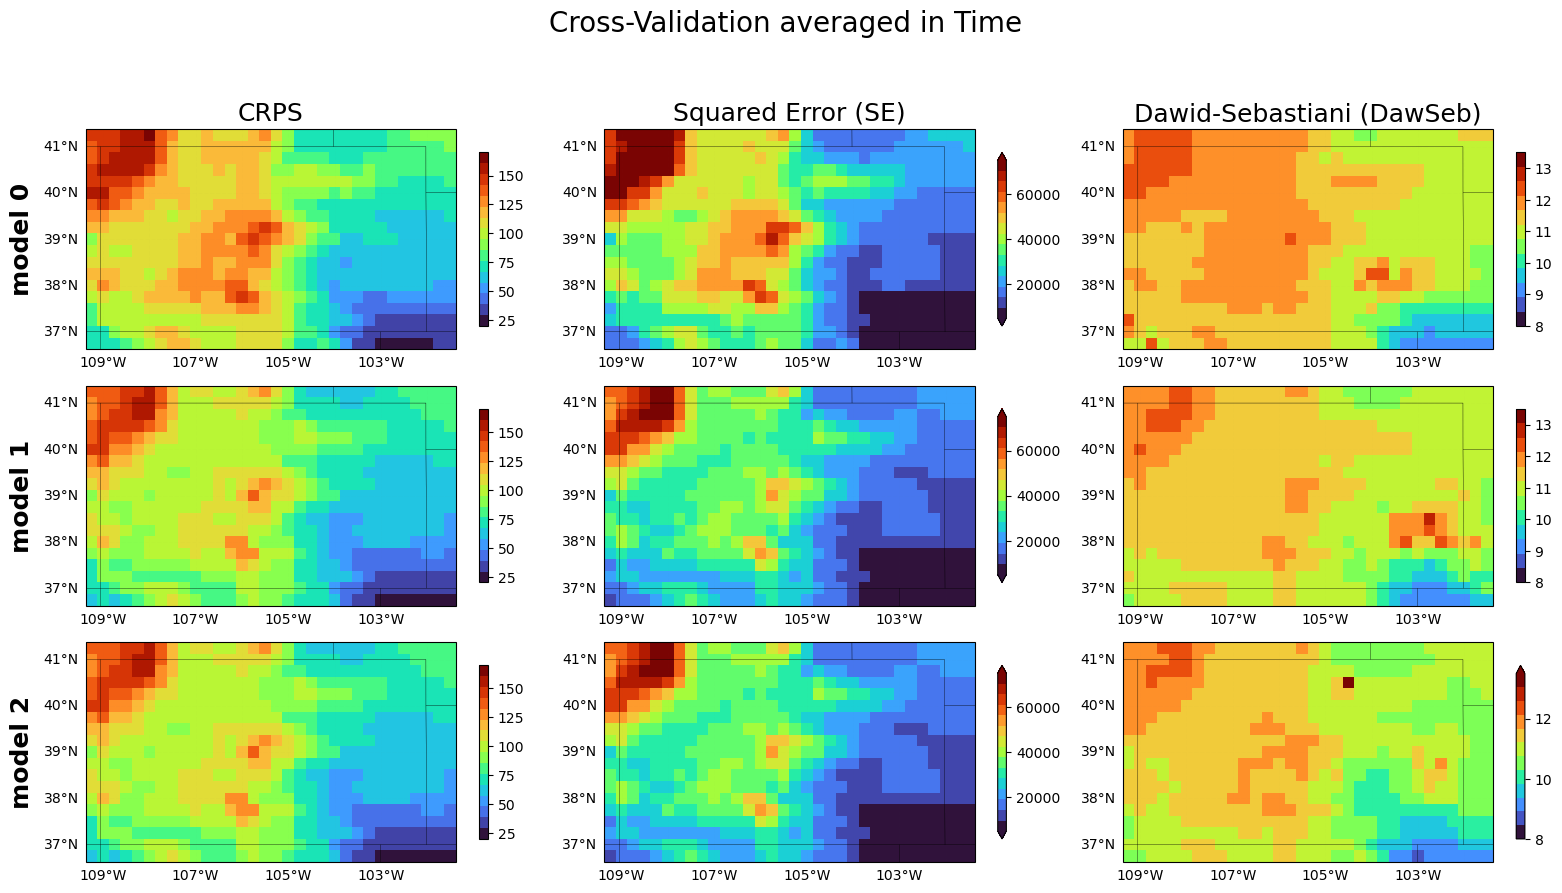

In [14]:
proj=ccrs.PlateCarree()


fig, ax = plt.subplots(nrows=3,ncols=3,figsize=(20,12),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.15, right=0.9,top=0.9,hspace=-0.04,wspace=0.12)
ax = ax.flatten()
clevs = np.arange(20,180,10)
cmap = plt.get_cmap('turbo',len(clevs)).copy()
cc = CRPS_cv0.mean('time').plot.pcolormesh(ax=ax[0],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.65,'label':''})
cc = CRPS_cv1.mean('time').plot.pcolormesh(ax=ax[3],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.65,'label':''})
cc = CRPS_cv1.mean('time').plot.pcolormesh(ax=ax[6],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.65,'label':''})
ax[0].set_title(f'CRPS',fontsize=18)  
ax[3].set_title(f'',fontsize=18)  
ax[6].set_title(f'',fontsize=18)  
clevs = np.arange(5000,80000,5000)
cmap = plt.get_cmap('turbo',len(clevs)).copy()
cc = SE_cv0.mean('time').plot.pcolormesh(ax=ax[1],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.65,'label':''})
cc = SE_cv1.mean('time').plot.pcolormesh(ax=ax[4],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.65,'label':''})
cc = SE_cv1.mean('time').plot.pcolormesh(ax=ax[7],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.65,'label':''})
ax[1].set_title(f'Squared Error (SE)',fontsize=18)  
ax[4].set_title(f'',fontsize=18)  
ax[7].set_title(f'',fontsize=18)  
clevs = np.arange(8,14,0.5)
cmap = plt.get_cmap('turbo',len(clevs)).copy()
cc = DawSeb_cv0.mean('time').plot.pcolormesh(ax=ax[2],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.65,'label':''})
cc = DawSeb_cv1.mean('time').plot.pcolormesh(ax=ax[5],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.65,'label':''})
cc = DawSeb_cv2.mean('time').plot.pcolormesh(ax=ax[8],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],cbar_kwargs={'shrink':0.65,'label':''})
ax[2].set_title(f'Dawid-Sebastiani (DawSeb)',fontsize=18)  
ax[5].set_title(f'',fontsize=18)  
ax[8].set_title(f'',fontsize=18)  
ax[0].text(-110.75+360,39,'model 0',color='k',size=18,weight='bold',transform = ccrs.PlateCarree(),rotation=90, ha='center', va='center')
ax[3].text(-110.75+360,39,'model 1',color='k',size=18,weight='bold',transform = ccrs.PlateCarree(),rotation=90, ha='center', va='center')
ax[6].text(-110.75+360,39,'model 2',color='k',size=18,weight='bold',transform = ccrs.PlateCarree(),rotation=90, ha='center', va='center')

for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=True, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
plt.suptitle(f'Cross-Validation averaged in Time',fontsize=20)  

Comparison of models scores averaged over time through the different splits. 

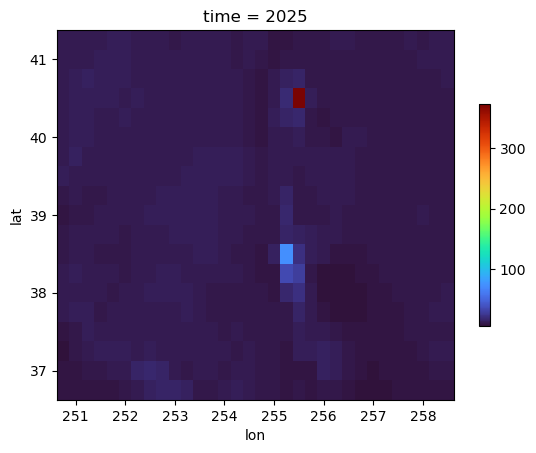

In [15]:
clevs = np.arange(8,20,0.5)
cmap = plt.get_cmap('turbo',len(clevs)).copy()
DawSeb_cv2.sel(time=2025).plot.pcolormesh(cmap='turbo',cbar_kwargs={'shrink':0.6,'label':''})

The problematic point seeing in the above figure for the model 2 Dawid-Sebastiani averaged score is coming from the test of the year 2025 by the associated split.

Text(0.5, 0.98, 'p values of the hypothesis test that models are pair-wise exchangeable')

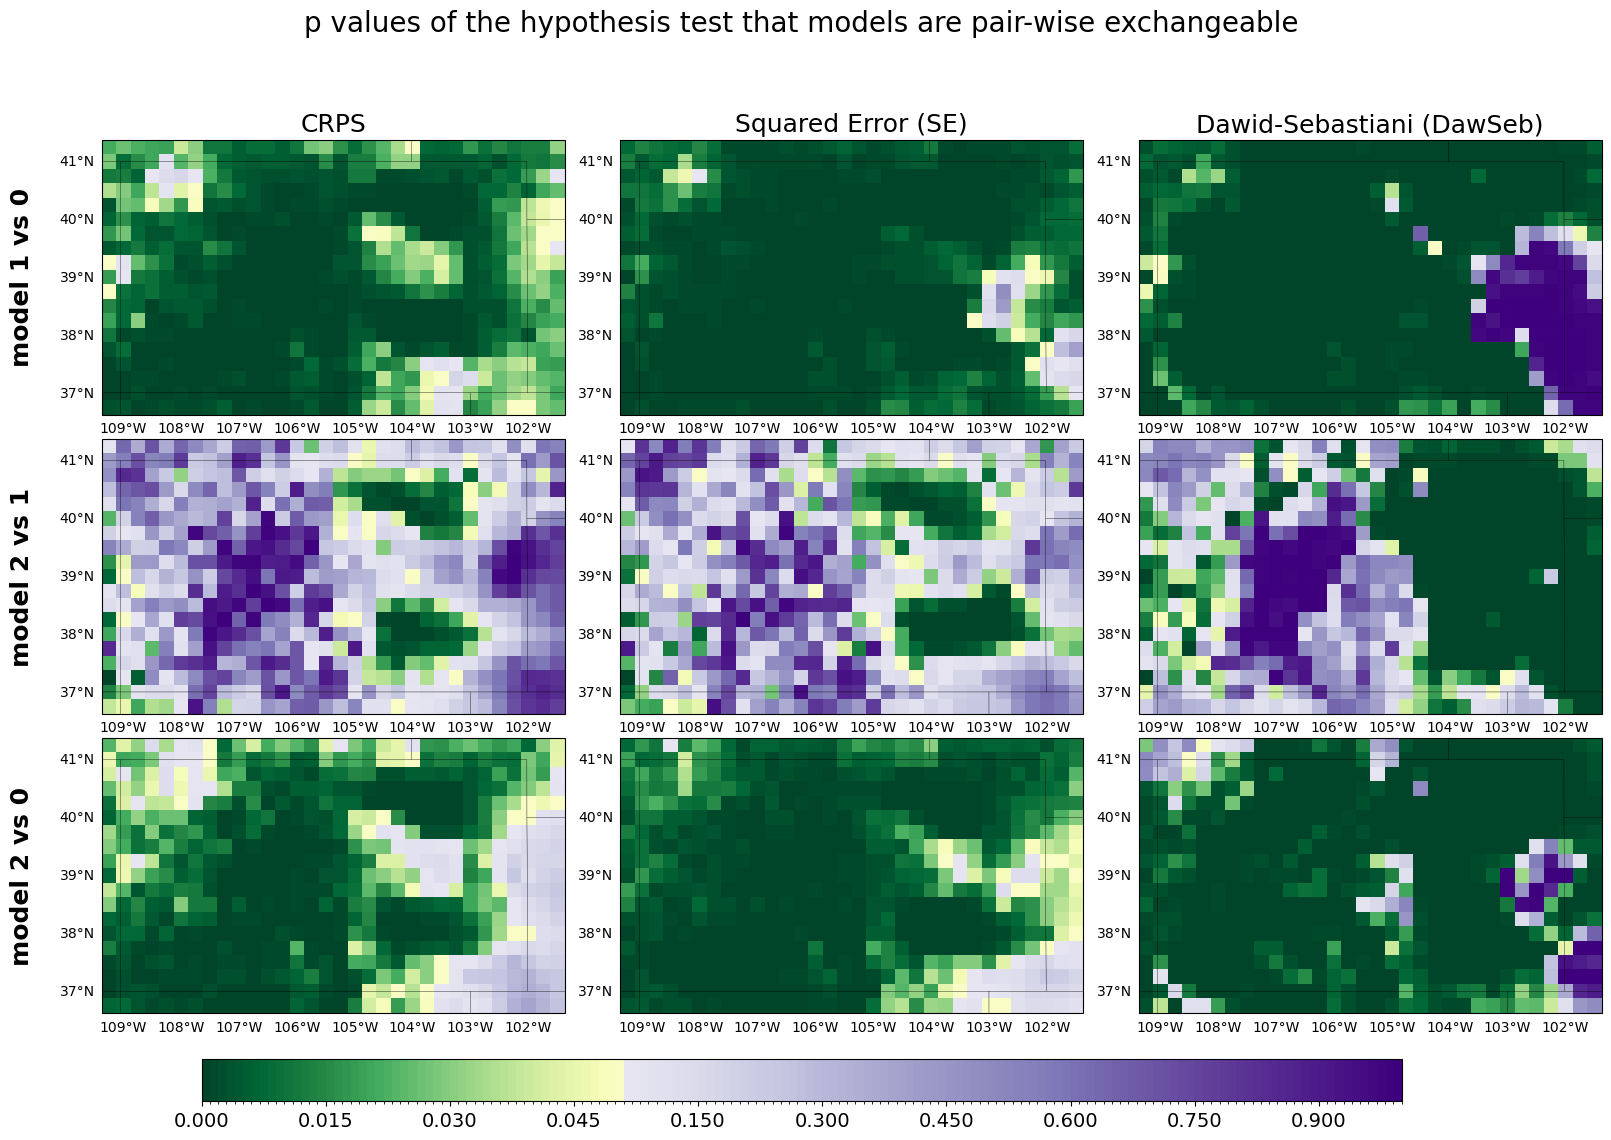

In [16]:
proj=ccrs.PlateCarree()


fig, ax = plt.subplots(nrows=3,ncols=3,figsize=(20,14),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.15, right=0.9,top=0.9,hspace=-0.04,wspace=0.12)
ax = ax.flatten()

cc = p_value_CRPS10.plot.pcolormesh(ax=ax[0],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)
cc = p_value_CRPS21.plot.pcolormesh(ax=ax[3],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)
cc = p_value_CRPS20.plot.pcolormesh(ax=ax[6],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)
ax[0].set_title(f'CRPS',fontsize=18)  
ax[3].set_title(f'',fontsize=18)  
ax[6].set_title(f'',fontsize=18)  

cc = p_value_SE10.plot.pcolormesh(ax=ax[1],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)
cc = p_value_SE21.plot.pcolormesh(ax=ax[4],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)
cc = p_value_SE20.plot.pcolormesh(ax=ax[7],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)
ax[1].set_title(f'Squared Error (SE)',fontsize=18)  
ax[4].set_title(f'',fontsize=18)  
ax[7].set_title(f'',fontsize=18)  

cc = p_value_DawSeb10.plot.pcolormesh(ax=ax[2],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)
cc = p_value_DawSeb21.plot.pcolormesh(ax=ax[5],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)
cc = p_value_DawSeb20.plot.pcolormesh(ax=ax[8],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)
ax[2].set_title(f'Dawid-Sebastiani (DawSeb)',fontsize=18)  
ax[5].set_title(f'',fontsize=18)  
ax[8].set_title(f'',fontsize=18)  
ax[0].text(-110.75+360,39,'model 1 vs 0',color='k',size=18,weight='bold',transform = ccrs.PlateCarree(),rotation=90, ha='center', va='center')
ax[3].text(-110.75+360,39,'model 2 vs 1',color='k',size=18,weight='bold',transform = ccrs.PlateCarree(),rotation=90, ha='center', va='center')
ax[6].text(-110.75+360,39,'model 2 vs 0',color='k',size=18,weight='bold',transform = ccrs.PlateCarree(),rotation=90, ha='center', va='center')

for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=True, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.03])

cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
#
plt.suptitle(f'p values of the hypothesis test that models are pair-wise exchangeable',fontsize=20)  

p values of the hypothesis test that the CRPS/SE/Dawid-Sebastiani scores for model 0, 1 and 2 are pair-wise exchangeable. The testing procedure is described in Appendix B. Failure to reject the null hypothesis would, informally, mean that the performances of models 1 vs 0 /2 vs 1/2 vs0 are statistically indistinguishable. 
The null hypothesis is rejected at the 0.05 level of significance in green.

Text(0.5, 0.98, 'ExtRemes comparison of Non-Stationnary Hypothesis')

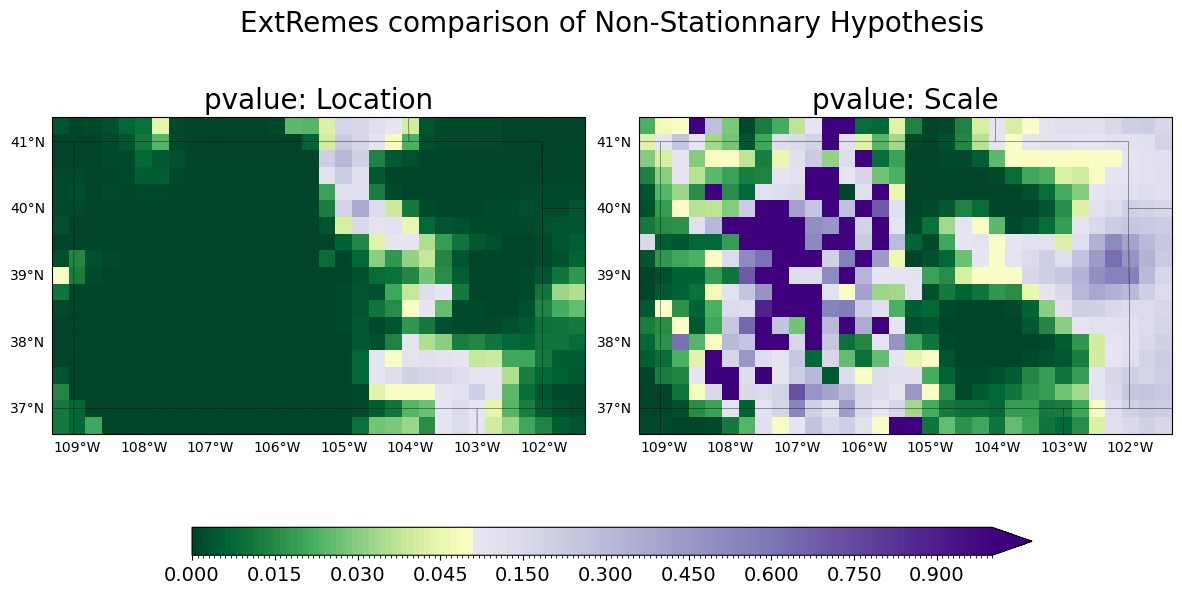

In [17]:
proj=ccrs.PlateCarree()
proj_data = ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})

plt.subplots_adjust(bottom=0.3,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.1)
ax = ax.flatten()

cc = pvalueL1.plot.pcolormesh(ax=ax[0],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)
ax[0].set_title(f'pvalue: Location',fontsize=20)  
cc = pvalueS2.plot.pcolormesh(ax=ax[1],cmap=pvalue_cmap,levels=clevs_pv,add_colorbar=False)
ax[1].set_title(f'pvalue: Scale',fontsize=20)  
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=True, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])

cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)

plt.suptitle(f'ExtRemes comparison of Non-Stationnary Hypothesis',fontsize=20)  

P value given by the extRemes package.

In [9]:
Tyears=[1950,1960,1970,1980,1990,2000,2010,2020,2025]
Tyears=[1941,2025]
AEP = [1/irp for irp in return_periods]
vq=[0.95,0.05]
proj=ccrs.PlateCarree()
Tquantile=['0.95','0.05']

In [10]:
import matplotlib.patches as mpatches

In [11]:
ptlon = [253.75,257.5]
ptlat = [ 39.5 , 37.5]

Text(0.5, 0.98, 'Fitted Location parameter 2025')

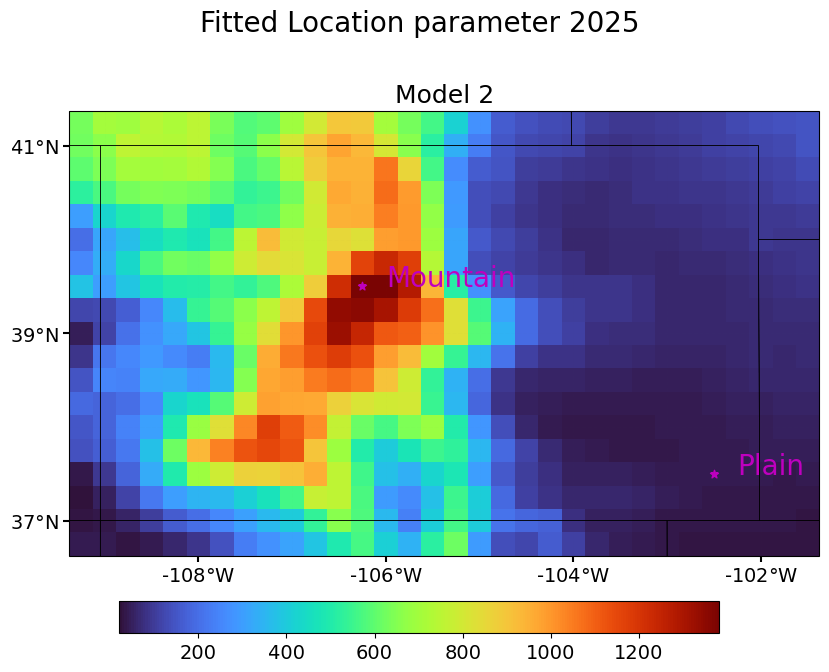

In [12]:
clevs = np.arange(-300,325,25)
cmap = 'turbo'
ptlabels = ['Mountain','Plain']

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.15, right=0.9,top=0.9,hspace=-0.04,wspace=0.12)

cc = Tlocation_q[2].sel(quantile=0.5,time=2025).plot.pcolormesh(ax=ax,cmap=cmap,add_colorbar=False)
ax.set_title(f'Model {2}',fontsize=18)   
##
for ip in range(0,2):
  ax.scatter(ptlon[ip],ptlat[ip],marker='*',color='m')
  ax.text(ptlon[ip]-360+0.25,ptlat[ip],f'{ptlabels[ip]}',color='m',size=20)
##
grd = ax.gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
ax.set_xlabel('')
ax.set_ylabel('')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
ax.coastlines()
ax.set_xticks(ax.get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax.get_xticks()],size=14)
ax.set_yticks(ax.get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)

plt.suptitle(f'Fitted Location parameter 2025',fontsize=20)  

Text(0.5, 0.98, 'Location parameter CI - Model 2')

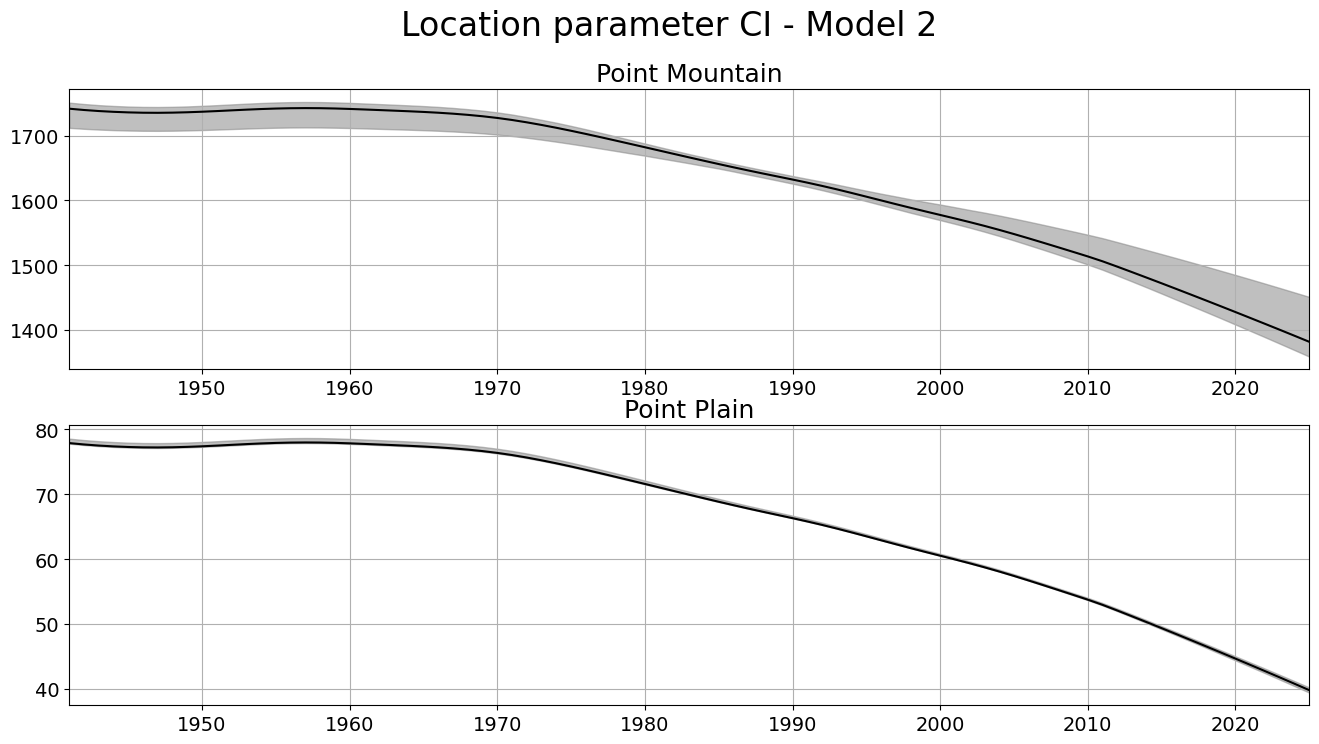

In [13]:
turbo_colors = colors=cm.get_cmap('turbo',26)

Ttitles=['Point Mountain','Point Plain']
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(16,8))
k=0
ax[0].plot(ds0.time,location_q2.sel(lon=ptlon[0],lat=ptlat[0],quantile=0.5),color='k')
ax[0].fill_between(ds0.time, location_q2.sel(lon=ptlon[0],lat=ptlat[0],quantile=0.05),\
                   location_q2.sel(lon=ptlon[0],lat=ptlat[0],quantile=0.95), 
                color='gray', alpha=0.5, label='Uncertainty')

ax[1].plot(ds0.time,location_q2.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.5),color='k')
ax[1].fill_between(ds0.time, location_q2.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.05),\
                   location_q2.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.95), 
                color='gray', alpha=0.5, label='Uncertainty')

for ix in range(0,len(ax)):
  ax[ix].grid()
  ax[ix].set_xlim(yearb,yeare)

  ax[ix].set_title(f'{Ttitles[ix]}',fontsize=18)
  #ax[ix].legend(loc='upper left',ncol=3,bbox_to_anchor=(0.09,0.99)) 
  ax[ix].tick_params(axis='both', labelsize=14)
plt.suptitle(f"Location parameter CI - Model 2",fontsize=24)

Text(0.5, 0.98, 'Scale parameter CI - Model 2')

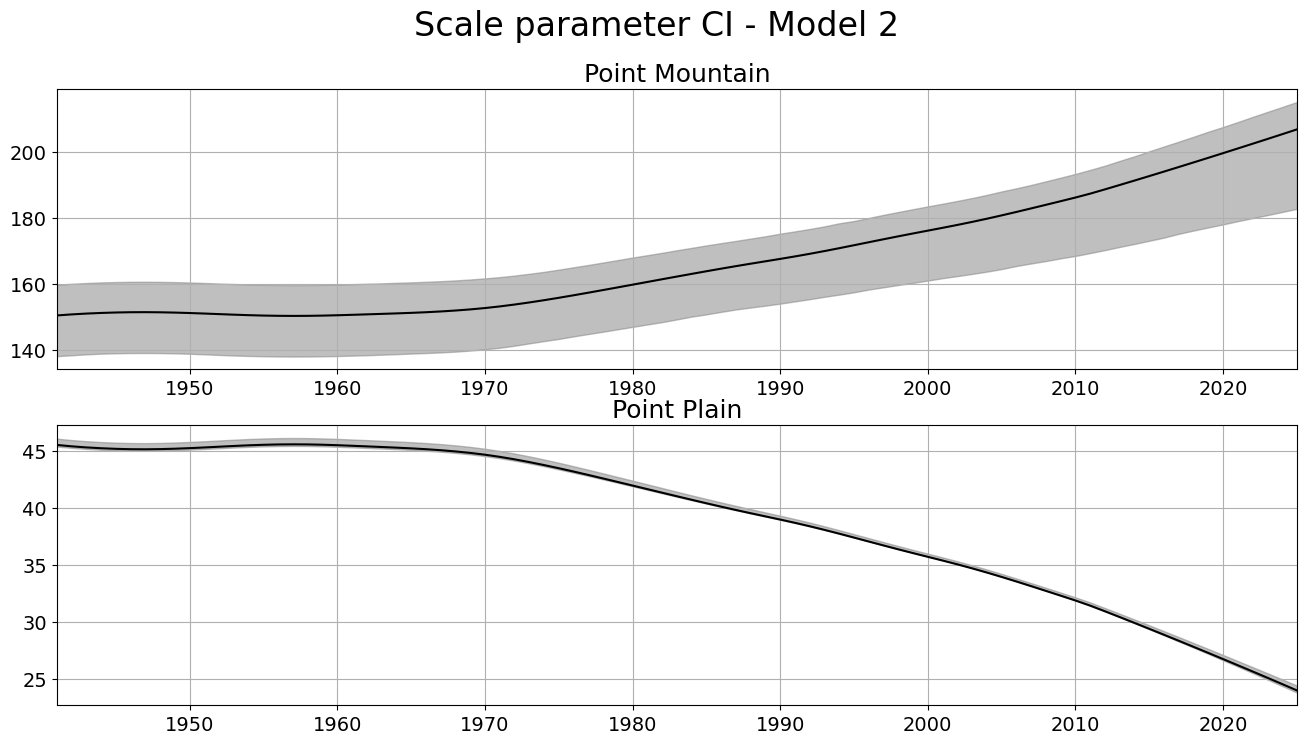

In [14]:
turbo_colors = colors=cm.get_cmap('turbo',26)

Ttitles=['Point Mountain','Point Plain']
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(16,8))
k=0
ax[0].plot(ds0.time,scale_q2.sel(lon=ptlon[0],lat=ptlat[0],quantile=0.5),color='k')
ax[0].fill_between(ds0.time, scale_q2.sel(lon=ptlon[0],lat=ptlat[0],quantile=0.05),\
                   scale_q2.sel(lon=ptlon[0],lat=ptlat[0],quantile=0.95), 
                color='gray', alpha=0.5, label='Uncertainty')

ax[1].plot(ds0.time,scale_q2.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.5),color='k')
ax[1].fill_between(ds0.time, scale_q2.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.05),\
                   scale_q2.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.95), 
                color='gray', alpha=0.5, label='Uncertainty')

for ix in range(0,len(ax)):
  ax[ix].grid()
  ax[ix].set_xlim(yearb,yeare)
  ax[ix].set_title(f'{Ttitles[ix]}',fontsize=18)
  #ax[ix].legend(loc='upper left',ncol=3,bbox_to_anchor=(0.09,0.99)) 
  ax[ix].tick_params(axis='both', labelsize=14)
plt.suptitle(f"Scale parameter CI - Model 2",fontsize=24)

Text(0.5, 0.98, 'Return Level CI - Model 2')

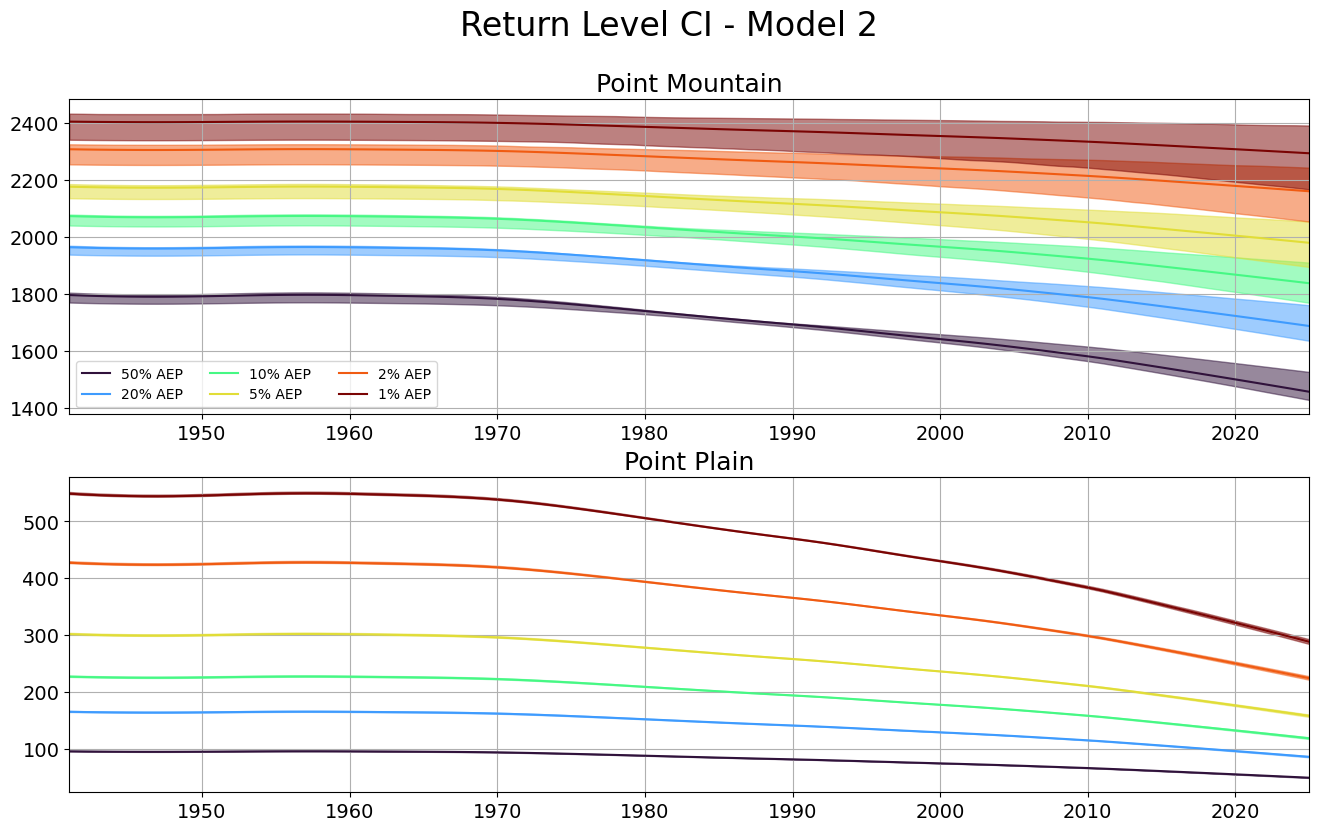

In [15]:
turbo_colors = colors=cm.get_cmap('turbo',6)

Ttitles=['Point Mountain','Point Plain']
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(16,9))
k=0
for irp in return_periods:
  ax[0].plot(ds0.time,rl_q2.sel(lon=ptlon[0],lat=ptlat[0],quantile=0.5,return_periods=irp),color=turbo_colors(k),label=f'{int(1/irp*100)}% AEP')
  ax[0].fill_between(ds0.time, rl_q2.sel(lon=ptlon[0],lat=ptlat[0],quantile=0.05,return_periods=irp),\
                   rl_q2.sel(lon=ptlon[0],lat=ptlat[0],quantile=0.95,return_periods=irp), 
                color=turbo_colors(k), alpha=0.5)
  k = k+1

k=0
for irp in return_periods:
  ax[1].plot(ds0.time,rl_q2.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.5,return_periods=irp),color=turbo_colors(k),label=f'{int(1/irp*100)}% AEP')
  ax[1].fill_between(ds0.time, rl_q2.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.05,return_periods=irp),\
                   rl_q2.sel(lon=ptlon[1],lat=ptlat[1],quantile=0.95,return_periods=irp), 
                color=turbo_colors(k), alpha=0.5)
  k = k+1

for ix in range(0,len(ax)):
  ax[ix].grid()
  ax[ix].set_xlim(yearb,yeare)
  ax[ix].set_title(f'{Ttitles[ix]}',fontsize=18)
  #ax[ix].legend(loc='upper left',ncol=3,bbox_to_anchor=(0.09,0.99)) 
  ax[ix].tick_params(axis='both', labelsize=14)
ax[0].legend(loc='lower left',ncol=3) 
plt.suptitle(f"Return Level CI - Model 2",fontsize=24)

In [76]:
return_periods

[2, 5, 10, 20, 50, 100]

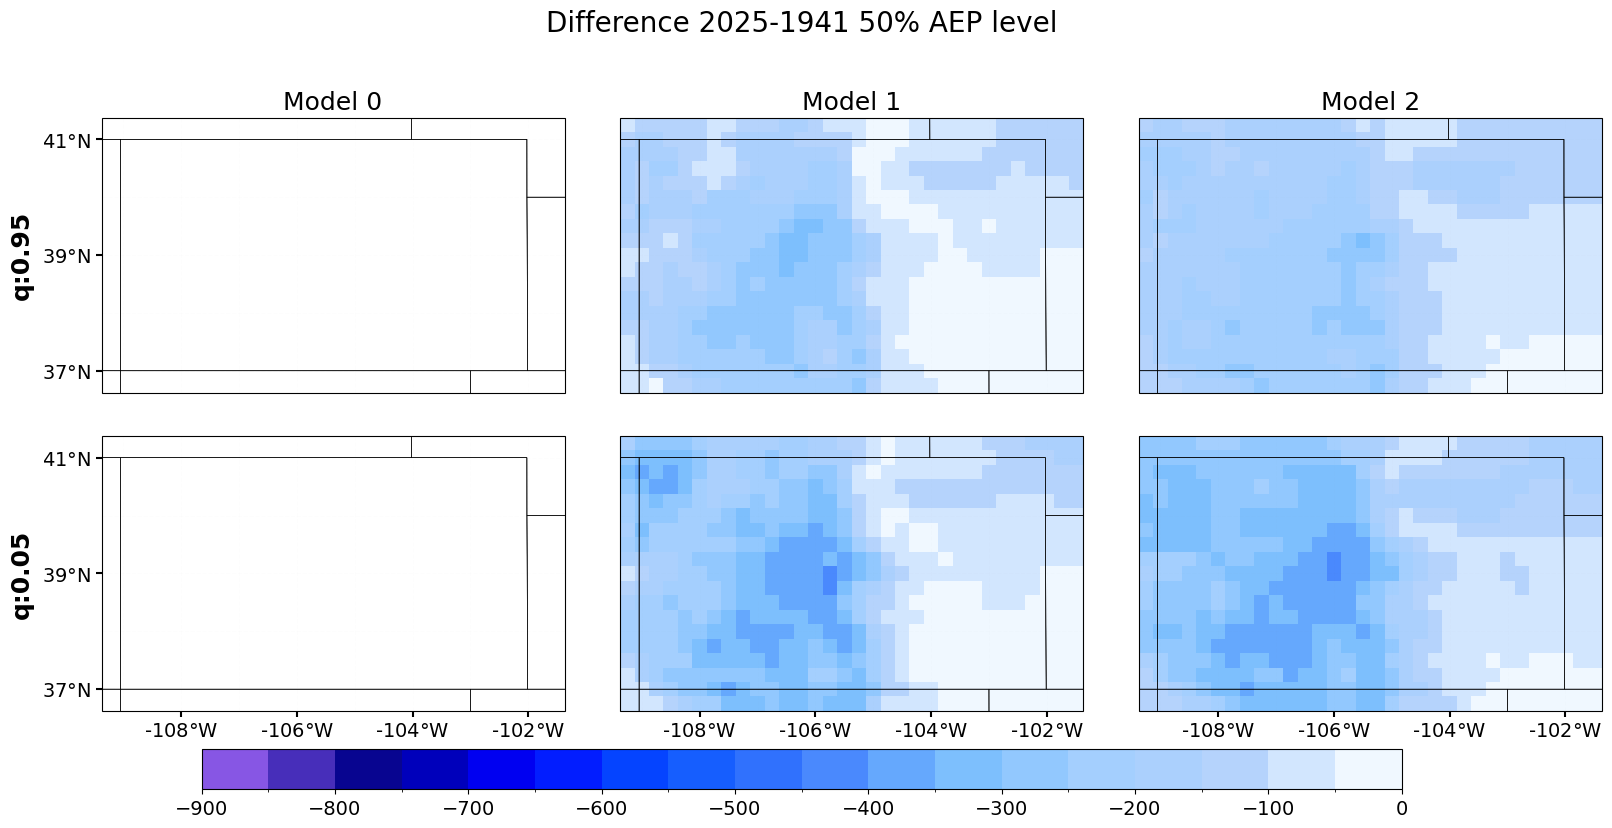

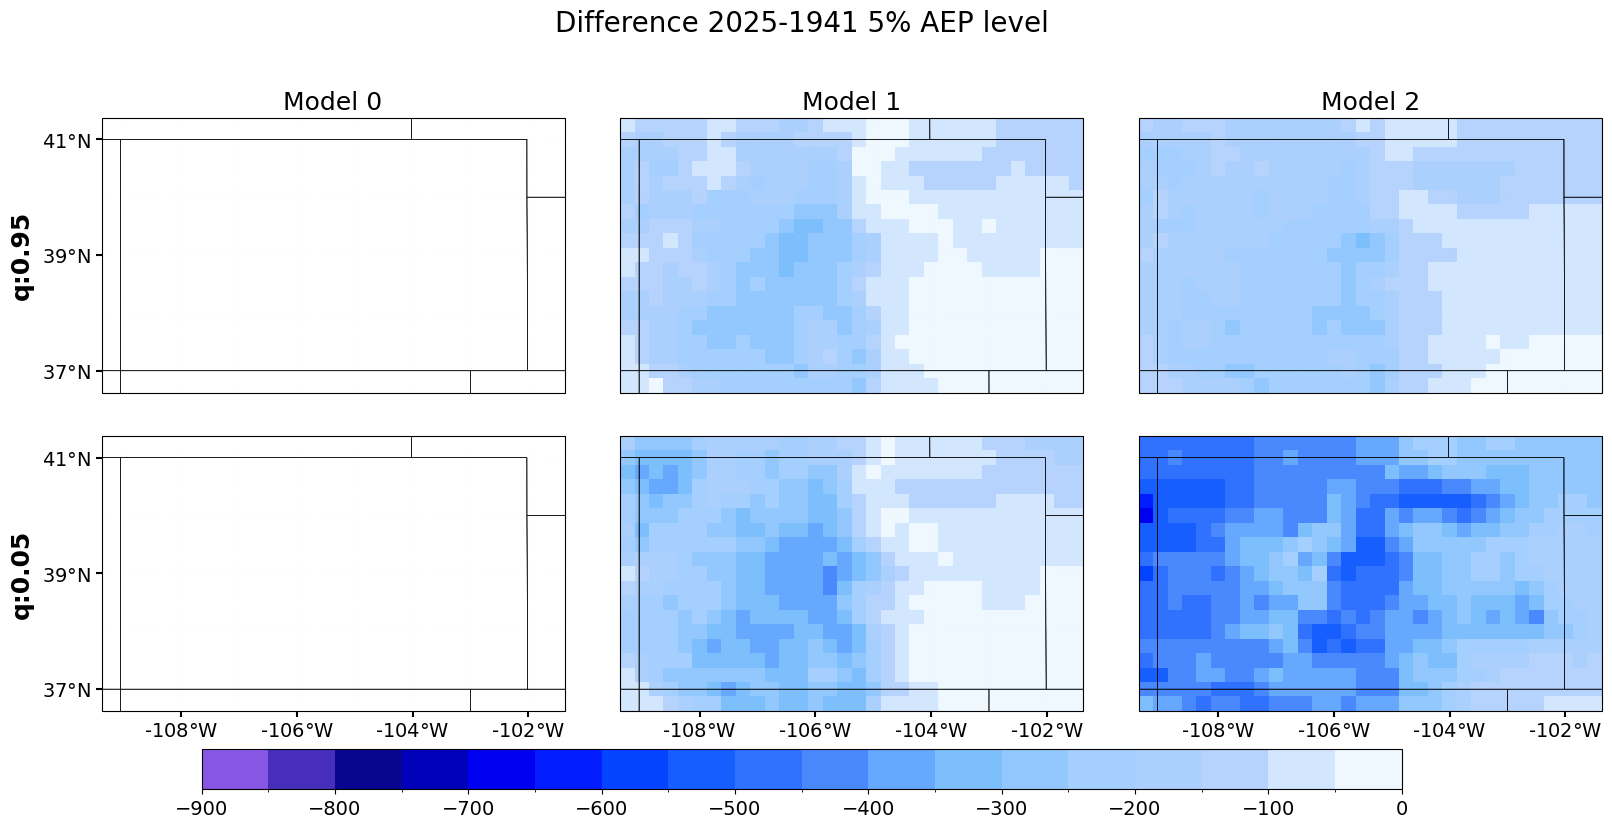

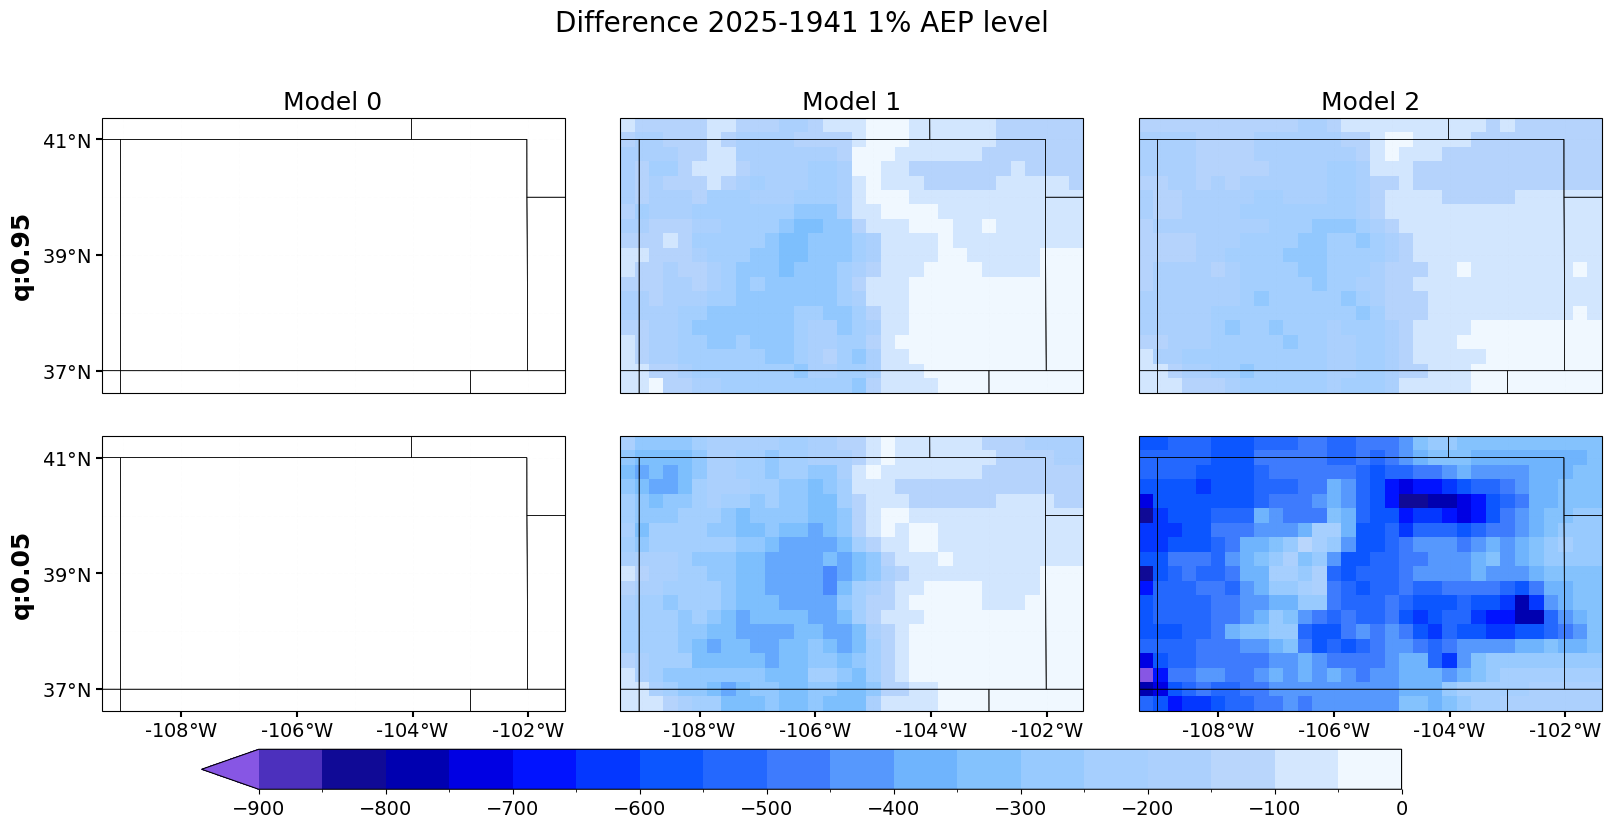

In [20]:
clevs = np.arange(-900,50,50)
cmap = Blues_map

Treturn_periods=[2,20,100]

for irp in Treturn_periods:
  fig, ax = plt.subplots(nrows=len(Tquantile),ncols=len(Trl),figsize=(20,10),subplot_kw={'projection':proj})
  plt.subplots_adjust(bottom=0.25,left=0.15, right=0.9,top=0.9,hspace=-0.04,wspace=0.12)
  ax = ax.flatten()
  for ix in range(0,len(Trl)):
    for iq in range(0,len(Tquantile)):
      cc = TDiffrl_q[ix].sel(quantile=vq[iq],return_periods=irp).plot.pcolormesh(ax=ax[ix+iq*len(Trl)],cmap=cmap,levels=clevs,add_colorbar=False)
      ax[ix+iq*len(Trl)].set_title(f'',fontsize=18)   
    ax[ix].set_title(f'Model {ix}',fontsize=18)   
  ax[0].text(-110.75+360,39,f'q:{Tquantile[0]}',color='k',size=18,weight='bold',transform = ccrs.PlateCarree(),rotation=90, ha='center', va='center')
  ax[len(Trl)].text(-110.75+360,39,f'q:{Tquantile[1]}',color='k',size=18,weight='bold',transform = ccrs.PlateCarree(),rotation=90, ha='center', va='center')
  ##
  for ix in range(0,len(ax)):
      ####
    grd = ax[ix].gridlines(
      draw_labels=False, 
      color='gray', alpha=0.01, linestyle='--')
    ax[ix].set_xlabel('')
    ax[ix].set_ylabel('')
    ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
    ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
    ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
    ax[ix].coastlines()
    if ix >=len(Trl):
      ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
      ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  for ix in range(0,len(ax),len(Trl)): 
    ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
  #
  ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
  cbar.ax.tick_params(labelsize=14)  
  cbar.set_label(label=f'',fontsize=16)

  plt.suptitle(f'Difference {yeare}-{yearb} {int(1/irp*100)}% AEP level',fontsize=20)  

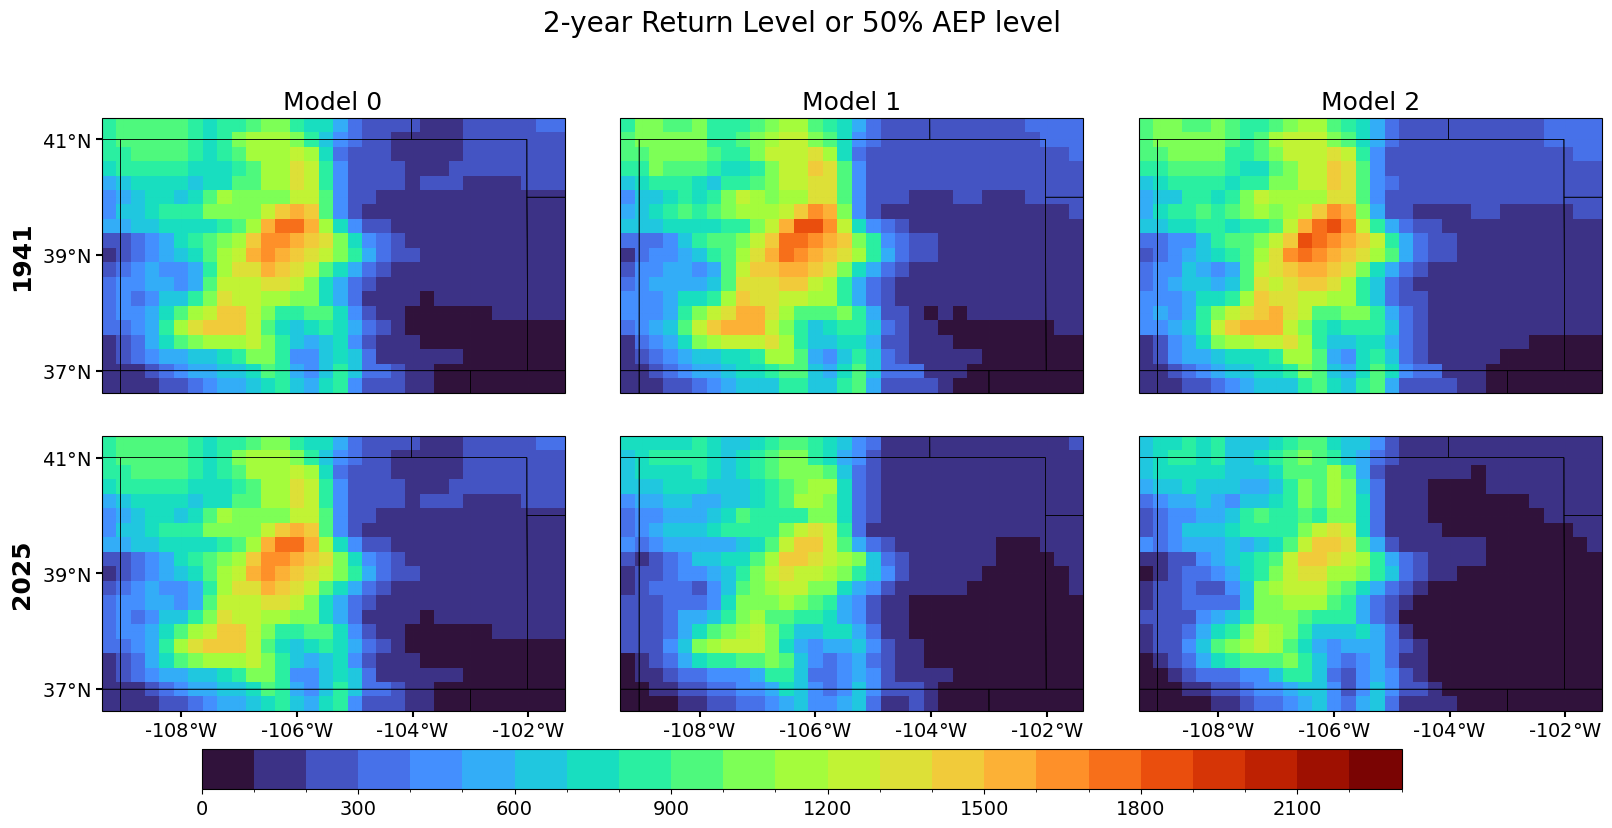

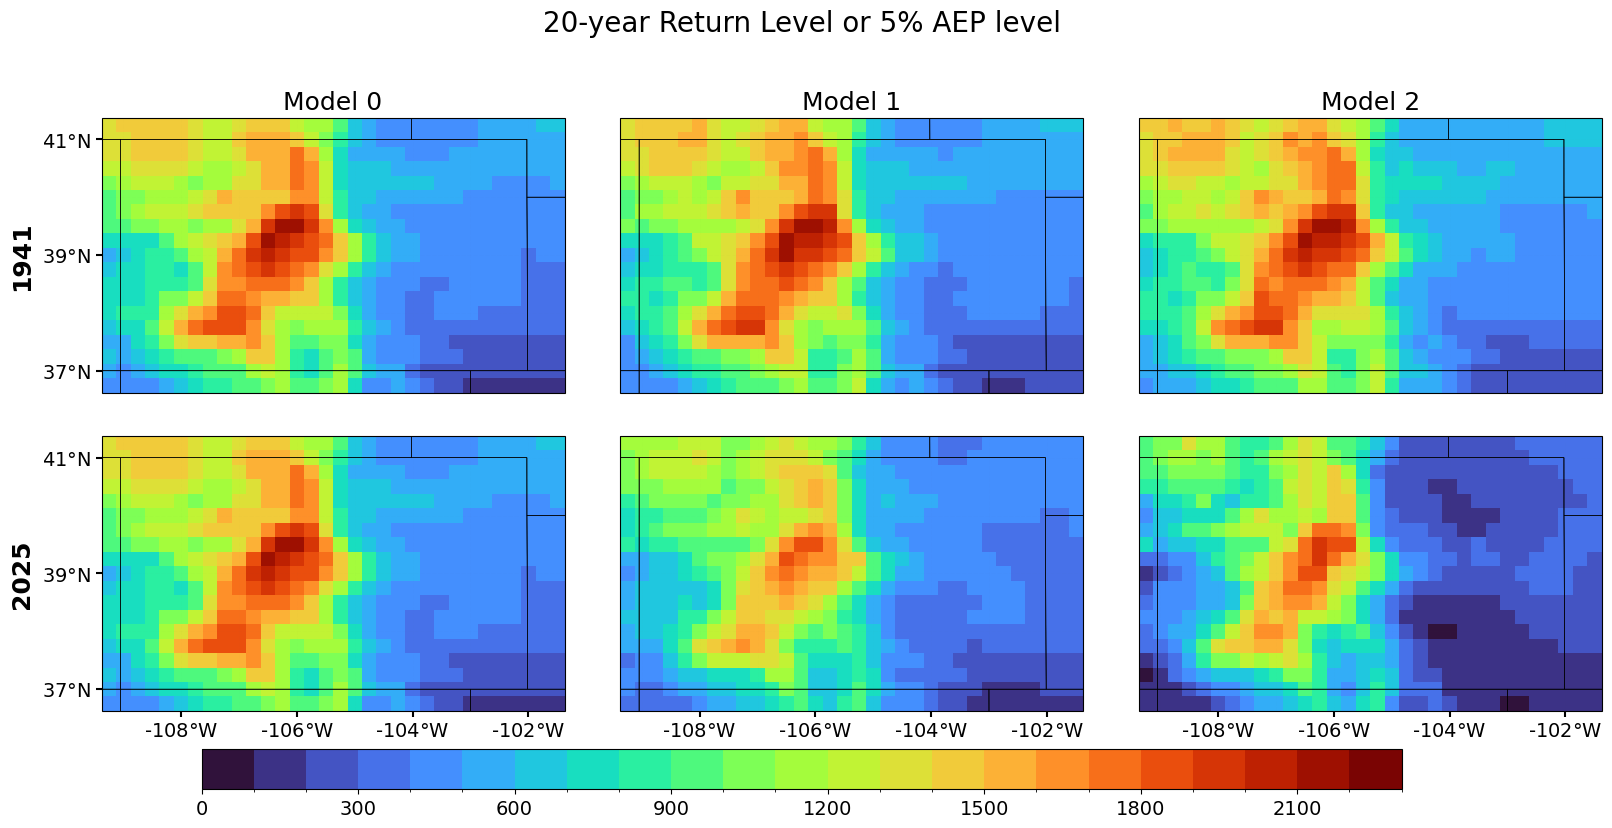

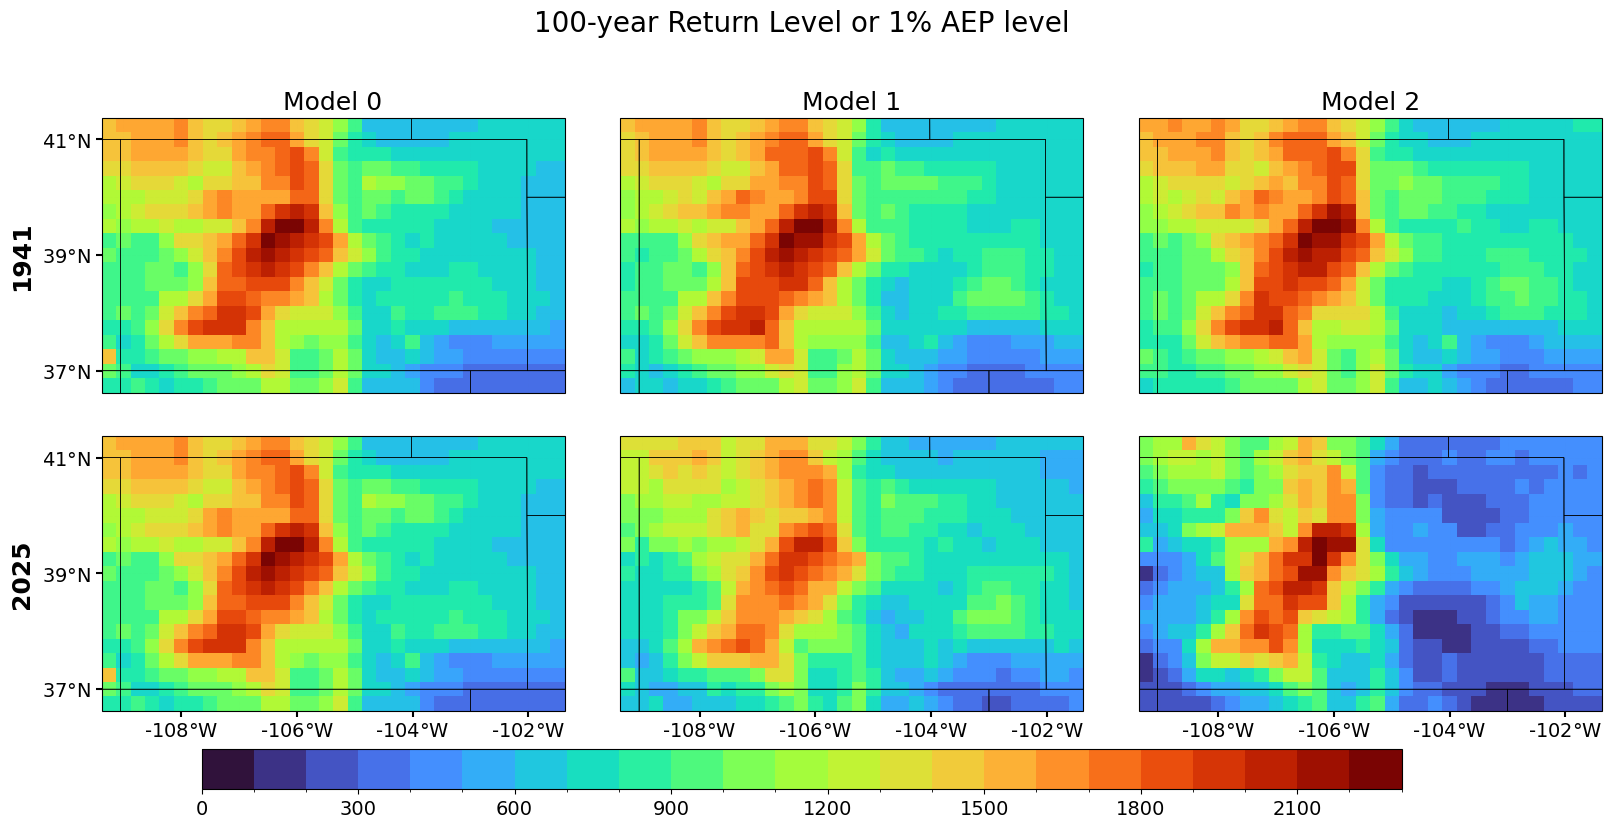

In [21]:
Tyears=[1941,2025]
proj=ccrs.PlateCarree()
proj_data = ccrs.PlateCarree()

clevs=np.arange(0,1700,100)
clevs=np.arange(0,2400,100)
cmap='turbo'
Treturn_periods=[2,20,100]

for irp in Treturn_periods:
  fig, ax = plt.subplots(nrows=len(Tyears),ncols=len(Trl),figsize=(20,10),subplot_kw={'projection':proj})
  plt.subplots_adjust(bottom=0.25,left=0.15, right=0.9,top=0.9,hspace=-0.04,wspace=0.12)
  ax = ax.flatten()
  for ix in range(0,len(Trl)):
    for iy in range(0,len(Tyears)):  
      cc = Trl[ix].sel(time=Tyears[iy],return_periods=irp).plot.pcolormesh(ax=ax[ix+iy*len(Trl)],cmap=cmap,levels=clevs,add_colorbar=False)
      ax[ix+iy*len(Trl)].set_title(f'',fontsize=18)   
    ax[ix].set_title(f'Model {ix}',fontsize=18)   
  ax[0].text(-110.75+360,39,f'{Tyears[0]}',color='k',size=18,weight='bold',transform = ccrs.PlateCarree(),rotation=90, ha='center', va='center')
  ax[len(Trl)].text(-110.75+360,39,f'{Tyears[1]}',color='k',size=18,weight='bold',transform = ccrs.PlateCarree(),rotation=90, ha='center', va='center')
  ##
  for ix in range(0,len(ax)):
    ####
    grd = ax[ix].gridlines(
      draw_labels=False, 
      color='gray', alpha=0.01, linestyle='--')
    ax[ix].set_xlabel('')
    ax[ix].set_ylabel('')
    ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
    ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
    ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
    ax[ix].coastlines()
    if ix >=len(Trl):
      ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
      ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  for ix in range(0,len(ax),len(Trl)): 
    ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
  #
  ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
  cbar.ax.tick_params(labelsize=14)  
  cbar.set_label(label=f'',fontsize=16)

  plt.suptitle(f'{irp}-year Return Level or {int(1/irp*100)}% AEP level',fontsize=20)  